# 학습 목표
- iceberg 아키텍처와 동작 흐름을 이해한다.
- PySpark SQL 을 이용해서 Iceberg 카탈로그, 테이블을 생성한다.
- PySpark SQL 을 이용해서 Iceberg 테이블 INSERT, UPDATE 해본다.

## 참고
- boto3 라이브러리가 없을 경우 `!python3 -m pip install boto3` 로 설치한다.
- fastavro 라이브러리가 없을 경우 `!python3 -m pip install fastavro` 로 설치한다.
- 학습 단계에서 사용하는 Iceberg 저장소: MinIO(S3 대체)
- 학습 단계에서 사용하는 Iceberg 카탈로그 서버: REST 카탈로그(sqlite 에 정보 기록)

---

In [1]:
# 페이지에 필요한 라이브러리 선언
from IPython.display import Image

---

# Iceberg 아키텍처

📋 Icebert 아키텍처


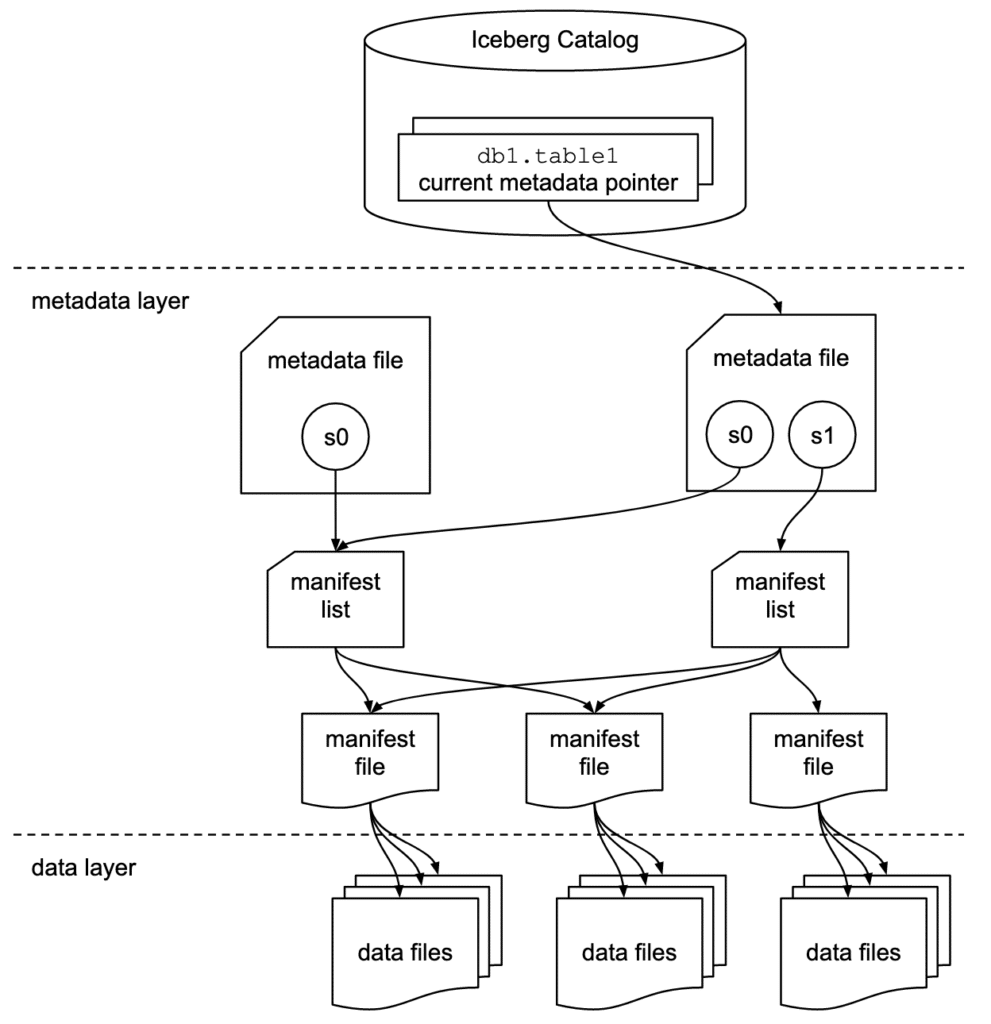

In [2]:
print("📋 Icebert 아키텍처")
Image("/home/iceberg/notebooks/images/iceberg_architecture.png")

> Iceberg 는 크게 카탈로그, 메타데이터, 데이터와 같이 3가지 레이어로 구분된다.

- **카탈로그 레이어**: REST, HIVE, GLUE 등의 카탈로그를 사용할 수 있다. 카탈로그, 네임스페이스(이하 데이터베이스), 테이블 등의 메타 정보를 관리한다.(*메타데이터 포인터 역할*)
- **메타데이터 레이어**: 실제 테이블의 메타 정보를 기록하여 JSON 또는 AVRO 파일로 관리한다.
- **데이타 레이어**: 테이블에 삽입 되는 실제 데이터를 관리하며 PARQUET 또는 ORC 등으로 관리한다.

> 각 레이어에 존재하는 파일들의 실행 흐름 예시는 다음과 같다.
> - 카탈로그 예시: my_catalog
> - 데이터베이스 예시: my_database
> - 테이블 예시: my_table

1. **CREATE (CATALOG, DATABASE)**  
   - 새로운 카탈로그와 데이터베이스를 생성하면, REST 서버에 연결된 sqlite DB(또는 다른 Catalog DB)에
     카탈로그명, 데이터베이스명, warehouse 경로 등이 등록된다.  
   - 즉, "이름표"와 "저장 위치" 같은 **최상위 메타데이터 관리 정보**가 기록된다.  
   - 이 단계에서는 아직 테이블 관련 메타데이터 파일이나 데이터 파일은 없다.

---

2. **CREATE (TABLE)**  
   - `my_table` 테이블을 처음 생성하면, REST 카탈로그는 이 테이블이  
     어느 카탈로그(`my_catalog`), 어느 데이터베이스(`my_database`)에 속하는지,  
     테이블 메타데이터는 어디 저장되는지, 소유자는 누구인지 등의 **테이블 기본 정보**를 관리한다.  
   - 실제 테이블에 대응하는 메타데이터 파일(`00000-...metadata.json`)이 MinIO 같은 저장소에 생성된다.  
   - 이 JSON에는 스키마 정보, 파티션 스펙, 소유자, 정렬 순서, 스냅샷 로그 등이 정의되며  
     REST 카탈로그의 포인터는 해당 JSON(예: `00000-...metadata.json`)을 최신 메타데이터로 가리킨다.  
   - **처음 테이블만 만들었을 때 데이터 파일(PARQUET 등)은 존재하지 않는다.**

---

3. **INSERT INTO**  
   - 데이터를 `my_table`에 삽입하면 새로운 스냅샷이 만들어지고,  
     새로운 메타데이터 파일(`00001-...metadata.json`)이 추가된다.  
   - REST 카탈로그 포인터는 최신 메타데이터(`00001-...metadata.json`)를 바라보게 된다.  
   - 동시에 실제 데이터는 **Parquet 파일** 형태로 저장소에 기록된다.  
   - 메타데이터 파일에는 이번 삽입 작업으로 생성된 **스냅샷 정보(snapshot)**와  
     데이터 파일 목록(Manifest List → Manifest File → Data File 경로)이 기록된다.  

---

4. **UPDATE (예: DELETE, MERGE, INSERT OVERWRITE 등)**  
   - Iceberg는 테이블 변경 시 "in-place update"가 아니라 **새로운 스냅샷을 추가**하는 방식으로 동작한다.  
   - 예를 들어, `UPDATE`나 `DELETE`를 수행하면 실제 데이터 파일을 직접 수정하지 않고,  
     새로운 스냅샷과 새로운 메타데이터 파일(`00002-...metadata.json`)을 만든다.  
   - 새로운 스냅샷에는 어떤 데이터 파일이 유효하고, 어떤 파일은 무효화되었는지가 기록된다.  
   - 따라서 Iceberg의 UPDATE는 사실상 **파일 레벨 append-only + 참조 갱신**으로 동작한다.  
   - REST 카탈로그는 항상 가장 최신 메타데이터 파일을 가리키며, 쿼리 시 Iceberg는 최신 스냅샷을 읽는다.  

---

📌 **정리**
- **카탈로그(DB)**: 테이블의 "주소록"과 "이름표" 관리  
- **메타데이터 파일(JSON)**: 스키마, 파티션, 스냅샷, 데이터 파일 경로 등 모든 이력 관리  
- **데이터 파일(Parquet 등)**: 실제 행(row) 데이터 저장소  
- 모든 변경(CREATE, INSERT, UPDATE)은 새로운 메타데이터/스냅샷을 생성하고,  
  REST 카탈로그 포인터는 항상 최신 메타데이터 파일을 가리킨다.


---

# PySpark Iceberg 실습

## Spark Session 설정

In [3]:
from pyspark.sql import SparkSession

# org.apache.iceberg.spark.SparkCatalog: Spark 전용 카탈로그 구현체 클래스
# spark.sql.catalog.my_catalog.uri: REST 카탈로그 서버의 엔드포인트 정보
# spark.sql.catalog.my_catalog.s3.endpoint: MinIO 스토리지 서버의 엔드포인트 정보
spark = SparkSession.builder \
        .appName("IcebergSparkWithMinIo") \
        .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
        .config("spark.sql.catalog.my_catalog.type", "rest") \
        .config("spark.sql.catalog.my_catalog.uri", "http://iceberg-rest:8181") \
        .config("spark.sql.catalog.my_catalog.warehouse", "s3://warehouse/") \
        .config("spark.sql.catalog.my_catalog.io-impl", "org.apache.iceberg.aws.s3.S3FileIO") \
        .config("spark.sql.catalog.my_catalog.s3.endpoint", "http://minio:9000") \
        .config("spark.sql.catalog.my_catalog.s3.access-key-id", "admin") \
        .config("spark.sql.catalog.my_catalog.s3.secret-access-key", "password") \
        .config("spark.sql.catalog.my_catalog.s3.path-style-access", "true") \
        .getOrCreate()

25/10/05 21:17:40 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## 카탈로그 및 데이터베이스(네임스페이스) 생성하기

In [4]:
spark.sql("CREATE DATABASE IF NOT EXISTS my_catalog.my_database")

DataFrame[]

In [5]:
spark.sql("SHOW CATALOGS").show()

+-------------+
|      catalog|
+-------------+
|         demo|
|   my_catalog|
|spark_catalog|
+-------------+



In [6]:
spark.sql("SHOW DATABASES IN my_catalog").show()

+-----------+
|  namespace|
+-----------+
|my_database|
+-----------+



In [8]:
spark.sql("SHOW TABLES IN my_database").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+



## 3. REST 카탈로그 API 살펴보기
- spark sql 로 작업을 제출하면 내부적으로 카탈로그 서버와 통신하기 위해 카탈로그 API 엔드포인트 주소를 기준으로 통신하게 된다.

In [7]:
# spark sql 을 이용해서 catalog, namespace(database), table 등을 생성하거나 데이터가 갱신 될 때 이와 같은 rest api 를 이용하여 내부적으로 통신한다.
! curl -s http://iceberg-rest:8181/v1/config

{"defaults":{},"overrides":{},"endpoints":["POST v1/oauth/tokens","POST https://auth-server.com/token","GET v1/config","GET /v1/{prefix}/namespaces","POST /v1/{prefix}/namespaces","HEAD /v1/{prefix}/namespaces/{namespace}","GET /v1/{prefix}/namespaces/{namespace}","DELETE /v1/{prefix}/namespaces/{namespace}","POST /v1/{prefix}/namespaces/{namespace}/properties","GET /v1/{prefix}/namespaces/{namespace}/tables","POST /v1/{prefix}/namespaces/{namespace}/tables","HEAD /v1/{prefix}/namespaces/{namespace}/tables/{table}","GET /v1/{prefix}/namespaces/{namespace}/tables/{table}","POST /v1/{prefix}/namespaces/{namespace}/register","POST /v1/{prefix}/namespaces/{namespace}/tables/{table}","DELETE /v1/{prefix}/namespaces/{namespace}/tables/{table}","POST /v1/{prefix}/tables/rename","POST /v1/{prefix}/namespaces/{namespace}/tables/{table}/metrics","POST /v1/{prefix}/transactions/commit","GET /v1/{prefix}/namespaces/{namespace}/views","HEAD /v1/{prefix}/namespaces/{namespace}/views/{view}","GET /v1

In [8]:
# 앞서 생성한 default_db 데이터베이스기 REST 카탈로그에 어떻게 저장 되어 있는지 조회한다.
! curl -s http://iceberg-rest:8181/v1/namespaces/default_db

{"namespace":["default_db"],"properties":{"owner":"root","location":"s3://warehouse/default_db"}}

In [9]:
# 현재까지는 default_db 데이터베이스에 등록된 테이블이 없다는 것을 알 수 있다.
! curl -s http://iceberg-rest:8181/v1/namespaces/default_db/tables

{"identifiers":[],"next-page-token":null}

## 4. MinIO bucket 생성하기
- 위와 같이 네임스페이스(DB)까지는 REST 카탈로그에만 데이터가 갱신 되기 때문에 MinIO 작업 없이 작업이 수행 되었지만,
- 테이블 생성부터 MinIO 에 메타데이터 등이 기록되기 때문에 먼저 MinIO 에 Bucket 을 만들어줘야한다.

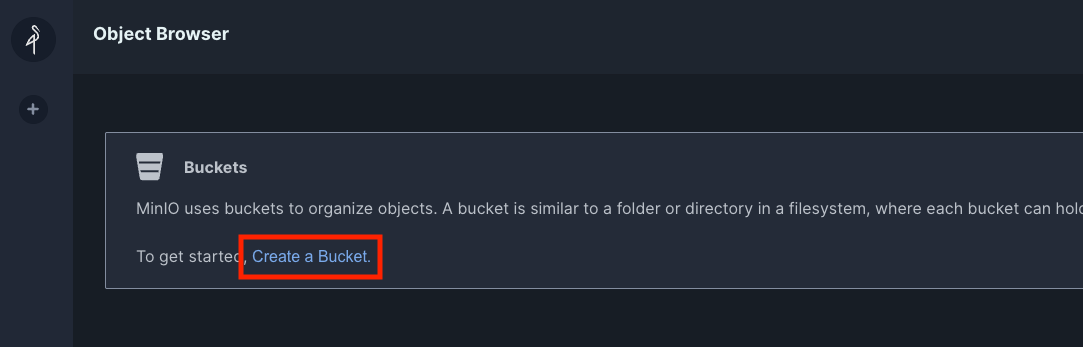

In [10]:
from IPython.display import Image, display
display(Image(filename="/home/iceberg/notebooks/images/minio_create_bucket.png"))

아래와 같이 warehouse 루트 경로를 `s3://warehouse/` 와 같이 설정하였기 때문에, bucket 이름을 warehouse로 생성하면 된다.
```python
.config("spark.sql.catalog.iceberg_catalog_for_jmkim.warehouse", "s3://warehouse/")
```

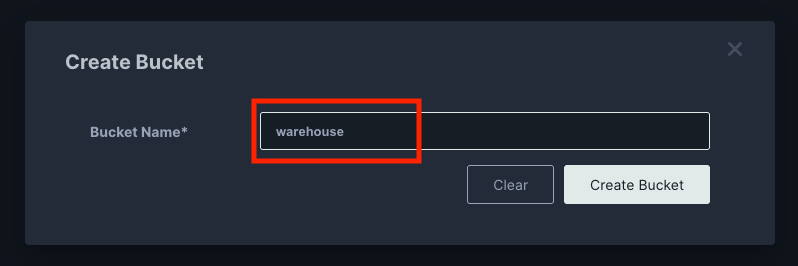

In [11]:
display(Image(filename="/home/iceberg/notebooks/images/minio_create_bucket_warehouse.png"))

warehouse 버킷을 처음 생성하면 하위에 아무것도 없는 것을 알 수 있다.

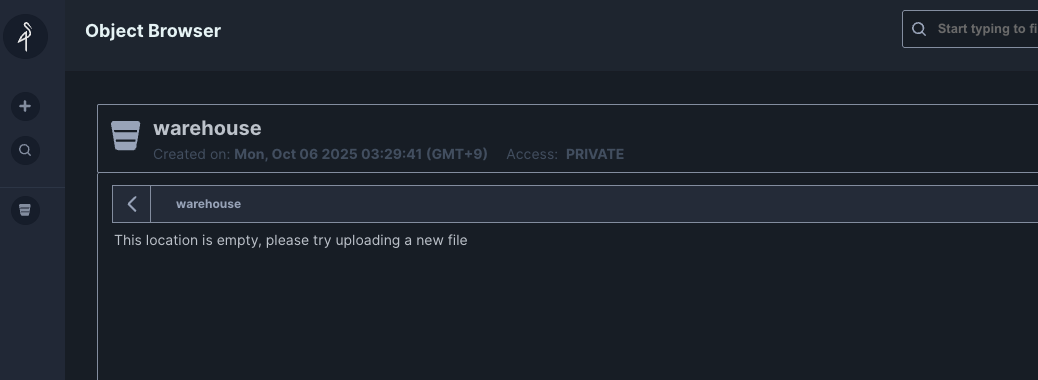

In [12]:
display(Image(filename="/home/iceberg/notebooks/images/minio_warehouse_bucket.png"))

## 5. 테이블 생성하기


In [15]:
# 앞에서 생성해둔 데이터베이스에 테이블을 생성한다.
spark.sql("""
CREATE TABLE IF NOT EXISTS iceberg_catalog_for_jmkim.default_db.my_first_table (
    id BIGINT,
    name STRING
) USING iceberg
""")

DataFrame[]

In [16]:
# 테이블 생성 후 데이터는 아직 없는 상태이다.
spark.sql("""
SELECT * FROM iceberg_catalog_for_jmkim.default_db.my_first_table
""").show()

+---+----+
| id|name|
+---+----+
+---+----+



- 테이블 생성 후 아래 이미지와 같이 warehouse 루트 경로 하위에 `warehouse/default_db/my_first_table/`와 같이 테이블 디렉토리가 생성되었다.
- 그리고 해당 테이블의 metadata 파일이 생성된 것도 확인할 수 있다.(metadata json 파일 이름은 스터디 환경 설정을 다시할 때마다 변경될 수 있다.)
- 처음 CREATE TABLE 후에는 data 파일이 존재하지 않는다.

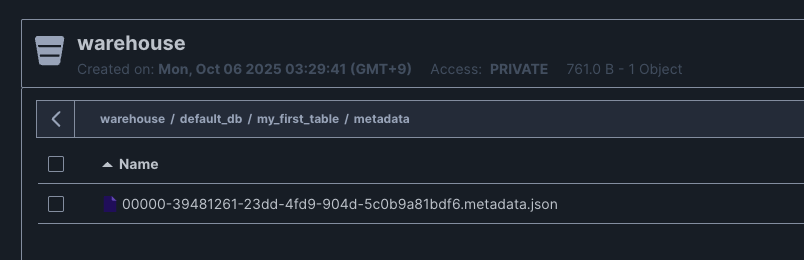

In [17]:
display(Image(filename="/home/iceberg/notebooks/images/minio_create_table.png"))

- 그리고 REST 카탈로그에서는 아래 API 호출 결과와 같이 `"metadata-location"` 필드를 통해 `my_first_table` 테이블의 최신 메타데이터 JSON 경로를 바라보고 있다. 이것이 `메타데이터 포인터` 역할을 하는 것이다.
- 데이터 갱신이 발생하여 메타데이터 JSON 이 새롭게 기록될 때마다. REST 카탈로그에서 `"metadata-location"` 필드의 경로가 갱신 되어 해당 테이블의 최신 메타데이터 JSON 경로를 계속 바라볼 수 있도록 한다.

In [19]:
! curl -s http://iceberg-rest:8181/v1/namespaces/default_db/tables/my_first_table

{"metadata-location":"s3://warehouse/default_db/my_first_table/metadata/00000-0cfedc66-db41-4314-8ad3-3c40d24ed63f.metadata.json","metadata":{"format-version":2,"table-uuid":"6c91a92f-b4ea-4997-adf9-80ebcd98e7c5","location":"s3://warehouse/default_db/my_first_table","last-sequence-number":0,"last-updated-ms":1759692983604,"last-column-id":2,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"name","required":false,"type":"string"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[]}],"last-partition-id":999,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":-1,"refs":{},"snapshots":[],"statistics":[],"partition-statistics":[],"snapshot-log":[],"metadata-log":[]}}

- 테이블 생성 후 생성된 metadata json 파일 내용을 살펴본다

In [22]:
# !python3 -m pip install boto3
!python3 -m pip list | grep boto3

boto3                     1.40.45

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [33]:
import boto3, json, datetime

def get_metadata_json(metadata_json):
    # MinIO S3 클라이언트 생성
    s3 = boto3.client(
        "s3",
        endpoint_url="http://minio:9000",
        aws_access_key_id="admin",
        aws_secret_access_key="password"
    )
    
    # Iceberg metadata.json 파일 읽기
    obj = s3.get_object(
        Bucket="warehouse",
        Key=f"default_db/my_first_table/metadata/{metadata_json}"
    )
    meta = json.loads(obj["Body"].read().decode("utf-8"))
    return meta

# 각 필드 설명 사전
field_descriptions = {
    "format-version": "Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/)",
    "table-uuid": "테이블을 고유하게 식별하는 UUID(데이터 갱신에도 변경되지 않는 정보)",
    "location": "테이블 데이터와 메타데이터가 저장되는 경로",
    "last-sequence-number": "마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 데이터갱신 작업마다 늘어남)",
    "last-updated-ms": "메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초)",
    "last-column-id": "현재까지 할당된 컬럼 ID 중 가장 큰 값",
    "current-schema-id": "현재 활성화된 스키마의 ID",
    "schemas": "테이블에서 사용 가능한 모든 스키마 정의 목록",
    "default-spec-id": "현재 기본 파티션 스펙 ID",
    "partition-specs": "파티션 정의 목록",
    "last-partition-id": "파티션 필드에 사용된 마지막 ID 값",
    "default-sort-order-id": "기본 정렬 순서의 ID",
    "sort-orders": "정렬 순서 정의 목록",
    "properties": "테이블 속성 (예: 소유자, 압축 코덱 등)",
    "current-snapshot-id": "현재 활성 스냅샷 ID (-1이면 스냅샷 없음)",
    "refs": "브랜치/태그 같은 참조 정보",
    "snapshots": "스냅샷 리스트 (데이터 변경 이력)",
    "statistics": "테이블 통계 정보",
    "partition-statistics": "파티션 단위 통계 정보",
    "snapshot-log": "스냅샷 변경 이력 로그",
    "metadata-log": "메타데이터 파일 변경 이력 로그"
}


def pretty_print_metadata(meta_dict):
    for key, value in meta_dict.items():
        desc = field_descriptions.get(key, "설명이 등록되지 않은 필드")
        if key == "last-updated-ms":
            # 밀리초 → 사람이 읽을 수 있는 시간 변환
            ts = datetime.datetime.fromtimestamp(value/1000.0)
            print(f"🔑 {key}: {desc}\n   ▶ 값 = {value} ({ts})\n")
        else:
            print(f"🔑 {key}: {desc}\n   ▶ 값 = {value}\n")

meta = get_metadata_json("00000-0cfedc66-db41-4314-8ad3-3c40d24ed63f.metadata.json")
pretty_print_metadata(meta)

🔑 format-version: Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/)
   ▶ 값 = 2

🔑 table-uuid: 테이블을 고유하게 식별하는 UUID(데이터 갱신에도 변경되지 않는 정보)
   ▶ 값 = 6c91a92f-b4ea-4997-adf9-80ebcd98e7c5

🔑 location: 테이블 데이터와 메타데이터가 저장되는 경로
   ▶ 값 = s3://warehouse/default_db/my_first_table

🔑 last-sequence-number: 마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 데이터갱신 작업마다 늘어남)
   ▶ 값 = 0

🔑 last-updated-ms: 메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초)
   ▶ 값 = 1759692983604 (2025-10-05 19:36:23.604000)

🔑 last-column-id: 현재까지 할당된 컬럼 ID 중 가장 큰 값
   ▶ 값 = 2

🔑 current-schema-id: 현재 활성화된 스키마의 ID
   ▶ 값 = 0

🔑 schemas: 테이블에서 사용 가능한 모든 스키마 정의 목록
   ▶ 값 = [{'type': 'struct', 'schema-id': 0, 'fields': [{'id': 1, 'name': 'id', 'required': False, 'type': 'long'}, {'id': 2, 'name': 'name', 'required': False, 'type': 'string'}]}]

🔑 default-spec-id: 현재 기본 파티션 스펙 ID
   ▶ 값 = 0

🔑 partition-specs: 파티션 정의 목록
   ▶ 값 = [{'spec-id': 0, 'fields': []}]

🔑 last-partition-id: 파티션 필드에 사용된 마지막 ID 값
   ▶ 값 = 999

🔑 default-sort-order-id: 기본 정렬 순서의 ID
   ▶ 값 =

## 6. INSERT(데이터 갱신하기)

In [24]:
spark.sql("""
INSERT INTO iceberg_catalog_for_jmkim.default_db.my_first_table
VALUES (1, 'Alice'), (2, 'Bob')
""")

DataFrame[]

In [25]:
spark.sql("""
SELECT * FROM iceberg_catalog_for_jmkim.default_db.my_first_table
""").show()

+---+-----+
| id| name|
+---+-----+
|  1|Alice|
|  2|  Bob|
+---+-----+



- 데이터 INSERT 이후 아래 이미지와 같이 `metadata.json`파일, manifest list(snap-*.avro)avro 파일, maifest file avro 파일이 생성된 것을 볼 수 있다.

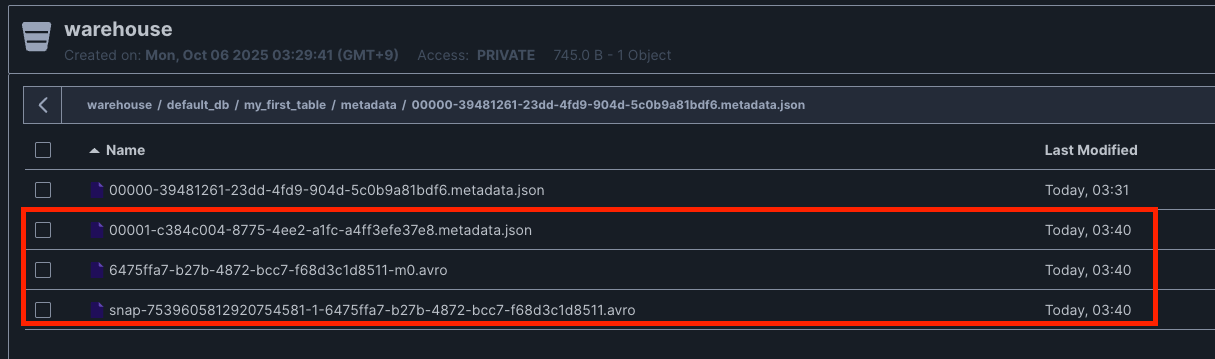

In [29]:
display(Image(filename="/home/iceberg/notebooks/images/minio_isnert_into_table.png"))

- 그리고 REST 카탈로그에서 `iceberg_catalog_for_jmkim.default_db.my_first_table` 테이블의 메타데이터 포인터가 최신 metadata.json 주소를 가르키도록 변경 된 것도 확인할 수 있다.
- 데이터가 추가 되면서 manifest list 주소도 추가 되었다.

In [26]:
! curl -s http://iceberg-rest:8181/v1/namespaces/default_db/tables/my_first_table

{"metadata-location":"s3://warehouse/default_db/my_first_table/metadata/00001-a0738d24-0131-4e2c-97c3-268358532e45.metadata.json","metadata":{"format-version":2,"table-uuid":"6c91a92f-b4ea-4997-adf9-80ebcd98e7c5","location":"s3://warehouse/default_db/my_first_table","last-sequence-number":1,"last-updated-ms":1759693102885,"last-column-id":2,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"id","required":false,"type":"long"},{"id":2,"name":"name","required":false,"type":"string"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[]}],"last-partition-id":999,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","write.parquet.compression-codec":"zstd"},"current-snapshot-id":5204657523439937389,"refs":{"main":{"snapshot-id":5204657523439937389,"type":"branch"}},"snapshots":[{"sequence-number":1,"snapshot-id":5204657523439937389,"timestamp-ms":1759693102885,"summary":{"operation":"append","sp

- INSERT 후 추가된 metadata.json 파일을 보면 아래와 같다.
- INSERT 후 스냅샷 정보가 추가된 것을 볼 수 있다. 해당 스냅샷 정보를 이용해서 iceberg 의 timetravel 기능을 사용할 수 있다.

In [35]:
meta = get_metadata_json("00001-a0738d24-0131-4e2c-97c3-268358532e45.metadata.json")
pretty_print_metadata(meta)

🔑 format-version: Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/)
   ▶ 값 = 2

🔑 table-uuid: 테이블을 고유하게 식별하는 UUID(데이터 갱신에도 변경되지 않는 정보)
   ▶ 값 = 6c91a92f-b4ea-4997-adf9-80ebcd98e7c5

🔑 location: 테이블 데이터와 메타데이터가 저장되는 경로
   ▶ 값 = s3://warehouse/default_db/my_first_table

🔑 last-sequence-number: 마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 데이터갱신 작업마다 늘어남)
   ▶ 값 = 1

🔑 last-updated-ms: 메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초)
   ▶ 값 = 1759693102885 (2025-10-05 19:38:22.885000)

🔑 last-column-id: 현재까지 할당된 컬럼 ID 중 가장 큰 값
   ▶ 값 = 2

🔑 current-schema-id: 현재 활성화된 스키마의 ID
   ▶ 값 = 0

🔑 schemas: 테이블에서 사용 가능한 모든 스키마 정의 목록
   ▶ 값 = [{'type': 'struct', 'schema-id': 0, 'fields': [{'id': 1, 'name': 'id', 'required': False, 'type': 'long'}, {'id': 2, 'name': 'name', 'required': False, 'type': 'string'}]}]

🔑 default-spec-id: 현재 기본 파티션 스펙 ID
   ▶ 값 = 0

🔑 partition-specs: 파티션 정의 목록
   ▶ 값 = [{'spec-id': 0, 'fields': []}]

🔑 last-partition-id: 파티션 필드에 사용된 마지막 ID 값
   ▶ 값 = 999

🔑 default-sort-order-id: 기본 정렬 순서의 ID
   ▶ 값 =

In [39]:
# !python3 -m pip install fastavro
! python3 -m pip list | grep fastavro

fastavro                  1.12.0

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [47]:
def get_metadata_avro(metadata_avro):
    import boto3, io, json
    from fastavro import reader as avro_reader
    
    s3 = boto3.client(
        "s3",
        endpoint_url="http://minio:9000",
        aws_access_key_id="admin",
        aws_secret_access_key="password"
    )
    
    # S3에서 Avro 파일 다운로드
    obj = s3.get_object(
        Bucket="warehouse",
        Key=f"default_db/my_first_table/metadata/{metadata_avro}"
    )

    # 4) Avro Reader로 파싱
    bio = io.BytesIO(obj["Body"].read())
    avro_rdr = avro_reader(bio)
    return avro_rdr

In [48]:
avro_meta = get_metadata_avro("snap-5204657523439937389-1-a9d46e23-b5da-4fd5-ab79-82abe6bb7bef.avro")

In [49]:
print("📑 Avro Schema:")
print(json.dumps(avro_meta.writer_schema, indent=2))

📑 Avro Schema:
{
  "type": "record",
  "name": "manifest_file",
  "fields": [
    {
      "field-id": 500,
      "doc": "Location URI with FS scheme",
      "name": "manifest_path",
      "type": "string"
    },
    {
      "field-id": 501,
      "doc": "Total file size in bytes",
      "name": "manifest_length",
      "type": "long"
    },
    {
      "field-id": 502,
      "doc": "Spec ID used to write",
      "name": "partition_spec_id",
      "type": "int"
    },
    {
      "field-id": 517,
      "doc": "Contents of the manifest: 0=data, 1=deletes",
      "name": "content",
      "type": "int"
    },
    {
      "field-id": 515,
      "doc": "Sequence number when the manifest was added",
      "name": "sequence_number",
      "type": "long"
    },
    {
      "field-id": 516,
      "doc": "Lowest sequence number in the manifest",
      "name": "min_sequence_number",
      "type": "long"
    },
    {
      "field-id": 503,
      "doc": "Snapshot ID that added the manifest",
      "

In [46]:
# Avro 레코드 출력 (앞에 몇 개만)
print("\n📑 Avro Records 샘플:")
for i, record in enumerate(avro_meta):
    print(json.dumps(record, indent=2, ensure_ascii=False))
    if i >= 4:  # 최대 5개까지만 출력
        break


📑 Avro Records 샘플:


In [8]:
spark.sql("""
UPDATE iceberg_catalog.default.my_table SET name = 'CHOITEST' WHERE id = 2
""")

DataFrame[]

In [9]:
spark.sql("""
SELECT * FROM iceberg_catalog.default.my_table
""").show()

+---+---------+
| id|     name|
+---+---------+
|  2| CHOITEST|
|  1|KIMJAEMIN|
+---+---------+



In [24]:
spark.sql("""
SELECT * FROM iceberg_catalog.default.my_table.snapshots
ORDER BY committed_at
""").show(truncate=True)

+--------------------+-------------------+-------------------+---------+--------------------+--------------------+
|        committed_at|        snapshot_id|          parent_id|operation|       manifest_list|             summary|
+--------------------+-------------------+-------------------+---------+--------------------+--------------------+
|2025-10-05 15:17:...|1639227104772827266|               NULL|   append|s3://warehouse/de...|{spark.app.id -> ...|
|2025-10-05 16:52:...|2656649516270997423|1639227104772827266|overwrite|s3://warehouse/de...|{spark.app.id -> ...|
+--------------------+-------------------+-------------------+---------+--------------------+--------------------+

